In [1]:


!pip install langgraph langchain langchain-google-genai google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.3 MB/s eta 0:00:00


In [2]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from IPython.display import Image

In [3]:
import os
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)


In [33]:
from typing import TypedDict, Literal

class SIMState(TypedDict):
    # Inputs from the User
    customer_name: str
    aadhaar_pan_status: str # e.g., 'VALID', 'INVALID'
    document_validity: str # e.g., 'VALID', 'INVALID'
    customer_location: str
    previous_sim_requests: int

    # Outputs from the workflow
    kyc_status: str
    fraud_risk: str
    final_decision: str

In [34]:
@tool
def customer_kyc_verification_tool(document_type: str, document_id: str) -> Literal["VERIFIED", "INVALID_DOCUMENT", "PENDING_VERIFICATION"]:
    """
    Validates customer KYC documents (Aadhaar/PAN) and checks their validity.

    Args:
        document_type (str): The type of the document (e.g., "Aadhaar", "PAN").
        document_id (str): The identification number of the document.

    Returns:
        Literal["VERIFIED", "INVALID_DOCUMENT", "PENDING_VERIFICATION"]:
            The verification status of the document.
    """
    # Simulate validation logic
    if document_type.lower() == "aadhaar" and document_id == "valid_aadhaar_123":
        return "VERIFIED"
    elif document_type.lower() == "pan" and document_id == "valid_pan_abc":
        return "VERIFIED"
    elif document_id == "invalid_doc_xyz":
        return "INVALID_DOCUMENT"
    else:
        return "PENDING_VERIFICATION"

In [35]:
@tool
def fraud_detection_tool(customer_location: str, num_previous_sim_requests: int, kyc_status: str) -> Literal["LOW_RISK", "MEDIUM_RISK", "HIGH_RISK"]:
    """
    Analyzes customer data to determine fraud risk using Gemini.

    Args:
        customer_location (str): The customer's geographical location.
        num_previous_sim_requests (int): The number of previous SIM card requests by the customer.
        kyc_status (str): The KYC verification status (e.g., 'VERIFIED', 'INVALID_DOCUMENT', 'PENDING_VERIFICATION').

    Returns:
        Literal["LOW_RISK", "MEDIUM_RISK", "HIGH_RISK"]:
            The classified fraud risk level.
    """
    prompt = f"""Analyze the following customer data for fraud risk and classify it as LOW_RISK, MEDIUM_RISK, or HIGH_RISK. Provide only the classification.

    Customer Location: {customer_location}
    Number of Previous SIM Requests: {num_previous_sim_requests}
    KYC Status: {kyc_status}

    Classification:"""

    response = llm.invoke(prompt)
    # Attempt to parse the classification from the response. Ensure it matches expected literals.
    response_text = response.content.strip().upper()

    if "HIGH_RISK" in response_text:
        return "HIGH_RISK"
    elif "MEDIUM_RISK" in response_text:
        return "MEDIUM_RISK"
    else:
        return "LOW_RISK" # Default to LOW_RISK if not explicitly HIGH or MEDIUM

In [36]:
@tool
def final_activation_decision_tool(fraud_classification: Literal["LOW_RISK", "MEDIUM_RISK", "HIGH_RISK"]) -> Literal["SIM Activated", "Manual Review", "Reject Application"]:
    """
    Determines the final activation decision based on the fraud classification.

    Args:
        fraud_classification (Literal["LOW_RISK", "MEDIUM_RISK", "HIGH_RISK"]):
            The fraud risk classification from the fraud detection tool.

    Returns:
        Literal["SIM Activated", "Manual Review", "Reject Application"]:
            The final decision for SIM activation.
    """
    if fraud_classification == "LOW_RISK":
        return "SIM Activated"
    elif fraud_classification == "MEDIUM_RISK":
        return "Manual Review"
    elif fraud_classification == "HIGH_RISK":
        return "Reject Application"
    else:
        # This case should ideally not be reached if fraud_classification is strictly one of the literals
        return "Manual Review" # Defaulting to manual review for unexpected inputs

In [37]:
def kyc_verification_node(state: SIMState) -> dict:
    kyc_status = customer_kyc_verification_tool.invoke({
        "document_type": state["aadhaar_pan_status"], # Assuming this maps to document_type
        "document_id": state["document_validity"]
    })
    return {"kyc_status": kyc_status}

In [38]:
def fraud_detection_node(state: SIMState) -> dict:
    fraud_classification = fraud_detection_tool.invoke({
        "customer_location": state["customer_location"],
        "num_previous_sim_requests": state["previous_sim_requests"],
        "kyc_status": state["kyc_status"]
    })
    return {"fraud_risk": fraud_classification}

In [39]:
def activation_decision_node(state: SIMState) -> dict:
    activation_decision = final_activation_decision_tool.invoke({
        "fraud_classification": state["fraud_risk"]
    })
    return {"final_decision": activation_decision}

In [40]:
sim_activation_graph = StateGraph(SIMState)

sim_activation_graph.add_node('kyc_verification', kyc_verification_node)
sim_activation_graph.add_node('fraud_detection', fraud_detection_node)
sim_activation_graph.add_node('activation_decision', activation_decision_node)

sim_activation_graph.set_entry_point('kyc_verification')

sim_activation_graph.add_edge(START, 'kyc_verification')
sim_activation_graph.add_edge('kyc_verification', 'fraud_detection')
sim_activation_graph.add_edge('fraud_detection', 'activation_decision')
sim_activation_graph.add_edge('activation_decision', END)

sim_activation_workflow = sim_activation_graph.compile()

print("SIM Activation Workflow compiled successfully!")

SIM Activation Workflow compiled successfully!


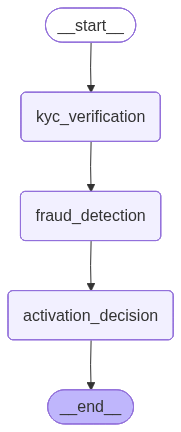

In [41]:
sim_activation_workflow

In [42]:

initial_sim_state_high_req: SIMState = {
    "customer_name": "sai",
    "aadhaar_pan_status": "VALID",
    "document_validity": "VALID",
    "customer_location": "Chennai",
    "previous_sim_requests": 10,
    "kyc_status": "",
    "fraud_risk": "",
    "final_decision": ""
}

result_sim_high_req = sim_activation_workflow.invoke(initial_sim_state_high_req)
print("Final State:", result_sim_high_req)

Final State: {'customer_name': 'sai', 'aadhaar_pan_status': 'VALID', 'document_validity': 'VALID', 'customer_location': 'Chennai', 'previous_sim_requests': 10, 'kyc_status': 'PENDING_VERIFICATION', 'fraud_risk': 'HIGH_RISK', 'final_decision': 'Reject Application'}


USE CASE 2: Healthcare Appointment Prioritization Workflow

In [50]:
from typing import TypedDict, Literal

class HealthcareState(TypedDict):
    # Inputs from the User
    fever: float
    oxygen_level: int # Percentage
    heart_rate: int
    symptom_duration: int # Hours
    patient_age: int
    existing_conditions: str # e.g., 'None', 'Diabetes', 'Heart Disease'

    # Outputs from the workflow
    severity_level: str # STABLE, MODERATE, CRITICAL
    priority_classification: str # EMERGENCY, PRIORITY_CONSULTATION, REGULAR_CONSULTATION
    consultation_type: str # ICU/ER, Specialist Doctor, General Physician

In [43]:
@tool
def severity_assessment_tool(fever: float, oxygen_level: int, heart_rate: int, symptom_duration: int, patient_age: int, existing_conditions: str) -> Literal["STABLE", "MODERATE", "CRITICAL"]:
    """
    Assesses the patient's severity level based on vital signs, symptoms, and medical history.

    Args:
        fever (float): Patient's body temperature in Celsius.
        oxygen_level (int): Patient's blood oxygen saturation level (percentage).
        heart_rate (int): Patient's heart rate (beats per minute).
        symptom_duration (int): Duration of symptoms in hours.
        patient_age (int): Age of the patient in years.
        existing_conditions (str): Pre-existing medical conditions (e.g., 'None', 'Diabetes', 'Heart Disease').

    Returns:
        Literal["STABLE", "MODERATE", "CRITICAL"]: The assessed severity level.
    """
    # Use LLM to assess severity based on detailed patient data
    prompt = f"""Assess the patient's condition for severity and classify it as STABLE, MODERATE, or CRITICAL. Provide only the classification.

    Fever: {fever}°C
    Oxygen Level: {oxygen_level}%
    Heart Rate: {heart_rate} bpm
    Symptom Duration: {symptom_duration} hours
    Patient Age: {patient_age} years
    Existing Conditions: {existing_conditions}

    Classification:"""

    response = llm.invoke(prompt)
    response_text = response.content.strip().upper()

    if "CRITICAL" in response_text:
        return "CRITICAL"
    elif "MODERATE" in response_text:
        return "MODERATE"
    else:
        return "STABLE"

In [44]:
@tool
def priority_classification_tool(severity_level: Literal["STABLE", "MODERATE", "CRITICAL"]) -> Literal["EMERGENCY", "PRIORITY_CONSULTATION", "REGULAR_CONSULTATION"]:
    """
    Classifies the appointment priority based on the patient's severity level.

    Args:
        severity_level (Literal["STABLE", "MODERATE", "CRITICAL"]): The assessed severity level.

    Returns:
        Literal["EMERGENCY", "PRIORITY_CONSULTATION", "REGULAR_CONSULTATION"]: The priority classification.
    """
    if severity_level == "CRITICAL":
        return "EMERGENCY"
    elif severity_level == "MODERATE":
        return "PRIORITY_CONSULTATION"
    else:
        return "REGULAR_CONSULTATION"

In [51]:
@tool
def consultation_recommendation_tool(priority_classification: Literal["EMERGENCY", "PRIORITY_CONSULTATION", "REGULAR_CONSULTATION"]) -> Literal["ICU/ER", "Specialist Doctor", "General Physician"]:
    """
    Recommends the type of medical consultation based on priority classification.

    Args:
        priority_classification (Literal["EMERGENCY", "PRIORITY_CONSULTATION", "REGULAR_CONSULTATION"]): The priority classification.

    Returns:
        Literal["ICU/ER", "Specialist Doctor", "General Physician"]: The recommended consultation type.
    """
    if priority_classification == "EMERGENCY":
        return "ICU/ER"
    elif priority_classification == "PRIORITY_CONSULTATION":
        return "Specialist Doctor"
    else:
        return "General Physician"

In [61]:
@tool
def consultation_assignment_tool(priority_classification: str) -> str:
    """Assigns the final consultation type based on the medical priority."""
    if priority_classification == 'EMERGENCY':
        return "ICU/ER"
    elif priority_classification == 'PRIORITY_CONSULTATION':
        return "Specialist Doctor"
    else:
        return "General Physician"

def Consultation_Assignment_Node(state: HealthcareState) -> HealthcareState:
    consultation_result = consultation_assignment_tool.invoke({"priority_classification": state['priority_classification']})
    state['consultation_type'] = consultation_result
    return state

In [62]:
healthcare_graph = StateGraph(HealthcareState)

healthcare_graph.add_node('severity_assessment', severity_assessment_node)
healthcare_graph.add_node('priority_classification', priority_classification_node)
healthcare_graph.add_node('consultation_recommendation', consultation_recommendation_node)

healthcare_graph.set_entry_point('severity_assessment')

healthcare_graph.add_edge(START, 'severity_assessment')
healthcare_graph.add_edge('severity_assessment', 'priority_classification')
healthcare_graph.add_edge('priority_classification', 'consultation_recommendation')
healthcare_graph.add_edge('consultation_recommendation', END)

healthcare_workflow = healthcare_graph.compile()

print("Healthcare Appointment Prioritization Workflow compiled successfully!")

Healthcare Appointment Prioritization Workflow compiled successfully!


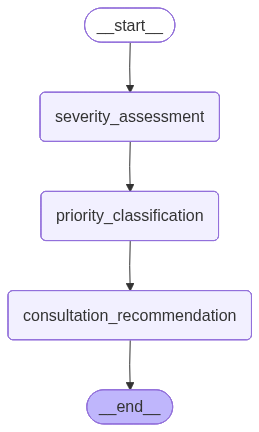

In [63]:
healthcare_workflow

In [56]:
sample_patient_data_critical: HealthcareState = {
    "fever": 39.5,
    "oxygen_level": 88,
    "heart_rate": 120,
    "symptom_duration": 48,
    "patient_age": 75,
    "existing_conditions": "Heart Disease, Diabetes",
    "severity_level": "",
    "priority_classification": "",
    "consultation_type": ""
}

result_critical = healthcare_workflow.invoke(sample_patient_data_critical)
print("Critical Case Final State:", result_critical)

Critical Case Final State: {'fever': 39.5, 'oxygen_level': 88, 'heart_rate': 120, 'symptom_duration': 48, 'patient_age': 75, 'existing_conditions': 'Heart Disease, Diabetes', 'severity_level': 'CRITICAL', 'priority_classification': 'EMERGENCY', 'consultation_type': 'ICU/ER'}


In [57]:
sample_patient_data_moderate: HealthcareState = {
    "fever": 38.0,
    "oxygen_level": 94,
    "heart_rate": 95,
    "symptom_duration": 24,
    "patient_age": 50,
    "existing_conditions": "None",
    "severity_level": "",
    "priority_classification": "",
    "consultation_type": ""
}

result_moderate = healthcare_workflow.invoke(sample_patient_data_moderate)
print("Moderate Case Final State:", result_moderate)

Moderate Case Final State: {'fever': 38.0, 'oxygen_level': 94, 'heart_rate': 95, 'symptom_duration': 24, 'patient_age': 50, 'existing_conditions': 'None', 'severity_level': 'MODERATE', 'priority_classification': 'PRIORITY_CONSULTATION', 'consultation_type': 'Specialist Doctor'}


In [58]:
sample_patient_data_stable: HealthcareState = {
    "fever": 37.0,
    "oxygen_level": 98,
    "heart_rate": 70,
    "symptom_duration": 6,
    "patient_age": 30,
    "existing_conditions": "None",
    "severity_level": "",
    "priority_classification": "",
    "consultation_type": ""
}

result_stable = healthcare_workflow.invoke(sample_patient_data_stable)
print("Stable Case Final State:", result_stable)

Stable Case Final State: {'fever': 37.0, 'oxygen_level': 98, 'heart_rate': 70, 'symptom_duration': 6, 'patient_age': 30, 'existing_conditions': 'None', 'severity_level': 'STABLE', 'priority_classification': 'REGULAR_CONSULTATION', 'consultation_type': 'General Physician'}
